In [1]:
import pandas as pd
import os.path
import pickle
import numpy as np
from tensorflow import keras
from tensorflow.keras import utils

In [10]:
d=pd.read_csv(r"C:\Users\HP\Downloads\train.tsv", sep='\t')
d

,Unnamed: 0,title,text,subject,date,label
0,2619,Ex-CIA head says Trump remarks on Russia inter...,Former CIA director John Brennan on Friday cri...,politicsNews,"July 22, 2017",1
1,16043,YOU WON’T BELIEVE HIS PUNISHMENT! HISPANIC STO...,How did this man come to OWN this store? There...,Government News,"Jun 19, 2017",0
2,876,Federal Reserve governor Powell's policy views...,President Donald Trump on Thursday tapped Fede...,politicsNews,"November 2, 2017",1
3,19963,SCOUNDREL HILLARY SUPPORTER STARTS “TrumpLeaks...,Hillary Clinton ally David Brock is offering t...,left-news,"Sep 17, 2016",0
4,10783,NANCY PELOSI ARROGANTLY DISMISSES Questions on...,Pleading ignorance is a perfect ploy for Nancy...,politics,"May 26, 2017",0
...,...,...,...,...,...,...
29995,6880,U.S. aerospace industry urges Trump to help Ex...,The chief executive of the U.S. Aerospace Indu...,politicsNews,"December 6, 2016",1
29996,17818,Highlights: Hong Kong leader Carrie Lam delive...,The following are highlights of the maiden pol...,worldnews,"October 11, 2017",1
29997,5689,Obama Literally LAUGHS At Claims That Brexit M...,If there s one thing President Barack Obama is...,News,"June 28, 2016",0
29998,15805,Syrian army takes full control of Deir al-Zor ...,The Syrian army and its allies have taken full...,worldnews,"November 2, 2017",1


In [11]:
print( d.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  30000 non-null  int64 
 1   title       30000 non-null  object
 2   text        30000 non-null  object
 3   subject     30000 non-null  object
 4   date        30000 non-null  object
 5   label       30000 non-null  int64 
dtypes: int64(2), object(4)
memory usage: 1.4+ MB
None


In [12]:
train_data = d.drop(d.columns[0], axis=1)

In [13]:
train_data

,title,text,subject,date,label
0,Ex-CIA head says Trump remarks on Russia inter...,Former CIA director John Brennan on Friday cri...,politicsNews,"July 22, 2017",1
1,YOU WON’T BELIEVE HIS PUNISHMENT! HISPANIC STO...,How did this man come to OWN this store? There...,Government News,"Jun 19, 2017",0
2,Federal Reserve governor Powell's policy views...,President Donald Trump on Thursday tapped Fede...,politicsNews,"November 2, 2017",1
3,SCOUNDREL HILLARY SUPPORTER STARTS “TrumpLeaks...,Hillary Clinton ally David Brock is offering t...,left-news,"Sep 17, 2016",0
4,NANCY PELOSI ARROGANTLY DISMISSES Questions on...,Pleading ignorance is a perfect ploy for Nancy...,politics,"May 26, 2017",0
...,...,...,...,...,...
29995,U.S. aerospace industry urges Trump to help Ex...,The chief executive of the U.S. Aerospace Indu...,politicsNews,"December 6, 2016",1
29996,Highlights: Hong Kong leader Carrie Lam delive...,The following are highlights of the maiden pol...,worldnews,"October 11, 2017",1
29997,Obama Literally LAUGHS At Claims That Brexit M...,If there s one thing President Barack Obama is...,News,"June 28, 2016",0
29998,Syrian army takes full control of Deir al-Zor ...,The Syrian army and its allies have taken full...,worldnews,"November 2, 2017",1


In [14]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    30000 non-null  object
 1   text     30000 non-null  object
 2   subject  30000 non-null  object
 3   date     30000 non-null  object
 4   label    30000 non-null  int64 
dtypes: int64(1), object(4)
memory usage: 1.1+ MB


In [15]:
train_data.duplicated().sum()

92

In [16]:
train_data.drop_duplicates(inplace=True)

In [17]:
train_data.duplicated().sum()

0

In [2]:
dataframe=pd.read_csv(r"C:\Users\HP\Downloads\test.tsv", sep='\t')
dataframe

,Unnamed: 0,title,text,subject,date,label
0,8104,Conservatives Will HATE What Donald Trump Just...,Donald Trump isn t exactly a stranger to makin...,News,"February 14, 2016",0
1,7467,Trump victory may create new tension between U...,Donald Trump’s U.S. election victory may creat...,politicsNews,"November 9, 2016",1
2,9473,WATCH: Hundreds of ILLEGAL ALIENS Storm Senate...,A couple of quick questions come to mind when ...,politics,"Nov 9, 2017",0
3,276,"Democratic Senator Franken to resign: CNN, cit...",U.S. Democratic Senator Al Franken will announ...,politicsNews,"December 7, 2017",1
4,19274,GANG OF DOMESTIC TERRORISTS Violently Attack L...,***WARNING*** Violence is graphic***This Trump...,left-news,"Jan 21, 2017",0
...,...,...,...,...,...,...
8262,5469,Russian MP says Flynn was forced to resign to ...,A senior Russian lawmaker said on Tuesday it w...,politicsNews,"February 14, 2017",1
8263,5079,Highlights: The Trump presidency on March 7 at...,Highlights of the day for U.S. President Donal...,politicsNews,"March 7, 2017",1
8264,20425,SHOCKER! WAS MUSLIM TERRORIST GAY? Used Gay Da...,"Of course, Mateen s Muslim father vehemently d...",left-news,"Jun 13, 2016",0
8265,22063,John McCain and The Cancer of Conflict,Patrick Henningsen 21st Century WireThis week ...,US_News,"July 21, 2017",0


In [3]:
test_data = dataframe.drop(dataframe.columns[0], axis=1)
test_data

,title,text,subject,date,label
0,Conservatives Will HATE What Donald Trump Just...,Donald Trump isn t exactly a stranger to makin...,News,"February 14, 2016",0
1,Trump victory may create new tension between U...,Donald Trump’s U.S. election victory may creat...,politicsNews,"November 9, 2016",1
2,WATCH: Hundreds of ILLEGAL ALIENS Storm Senate...,A couple of quick questions come to mind when ...,politics,"Nov 9, 2017",0
3,"Democratic Senator Franken to resign: CNN, cit...",U.S. Democratic Senator Al Franken will announ...,politicsNews,"December 7, 2017",1
4,GANG OF DOMESTIC TERRORISTS Violently Attack L...,***WARNING*** Violence is graphic***This Trump...,left-news,"Jan 21, 2017",0
...,...,...,...,...,...
8262,Russian MP says Flynn was forced to resign to ...,A senior Russian lawmaker said on Tuesday it w...,politicsNews,"February 14, 2017",1
8263,Highlights: The Trump presidency on March 7 at...,Highlights of the day for U.S. President Donal...,politicsNews,"March 7, 2017",1
8264,SHOCKER! WAS MUSLIM TERRORIST GAY? Used Gay Da...,"Of course, Mateen s Muslim father vehemently d...",left-news,"Jun 13, 2016",0
8265,John McCain and The Cancer of Conflict,Patrick Henningsen 21st Century WireThis week ...,US_News,"July 21, 2017",0


In [4]:
test_data.duplicated().sum()

10

In [14]:
test_data.drop_duplicates(inplace=True)

In [15]:
test_data.duplicated().sum()

0

In [16]:
import nltk
nltk.download('punkt')


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [17]:
import nltk
nltk.download('all')  # This will download all NLTK resources

[nltk_data] Downloading collection 'all'
[nltk_data]    | 
[nltk_data]    | Downloading package abc to
[nltk_data]    |     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]    |   Package abc is already up-to-date!
[nltk_data]    | Downloading package alpino to
[nltk_data]    |     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]    |   Package alpino is already up-to-date!
[nltk_data]    | Downloading package averaged_perceptron_tagger to
[nltk_data]    |     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]    |   Package averaged_perceptron_tagger is already up-
[nltk_data]    |       to-date!
[nltk_data]    | Downloading package averaged_perceptron_tagger_eng to
[nltk_data]    |     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]    |   Package averaged_perceptron_tagger_eng is already
[nltk_data]    |       up-to-date!
[nltk_data]    | Downloading package averaged_perceptron_tagger_ru to
[nltk_data]    |     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]    |

True

In [18]:
# Install required packages
!pip install textblob textstat xgboost nltk scikit-learn pandas numpy matplotlib seaborn

# Download necessary NLTK resources
import nltk
nltk.download('punkt')




   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ---------------------------------------- 2.1/2.1 MB 14.5 MB/s eta 0:00:00


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [ ]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import re
import string

def extract_text_features(text):
    """Extract features related to text quality, readability, and punctuation."""
    # Convert to string if not already
    text = str(text)
    
    # Basic text statistics
    word_count = len(text.split())
    avg_word_length = np.mean([len(word) for word in text.split()]) if word_count > 0 else 0
    
    # Punctuation features
    exclamation_count = text.count('!')
    question_count = text.count('?')
    ellipsis_count = text.count('...')
    
    # Calculate ratio of uppercase words
    words = text.split()
    uppercase_ratio = sum(1 for word in words if word.isupper()) / len(words) if words else 0
    
    # Sentence features
    sentences = [s.strip() for s in re.split('[.!?]+', text) if s.strip()]
    avg_sentence_length = np.mean([len(s.split()) for s in sentences]) if sentences else 0
    
    # Count spelling indicators (repeated letters)
    repeated_chars = len(re.findall(r'(.)\1{2,}', text))
    
    # Punctuation density
    total_puncts = sum(1 for char in text if char in string.punctuation)
    punct_density = total_puncts / len(text) if len(text) > 0 else 0
    
    # Count potential spam indicators
    caps_sections = len(re.findall(r'[A-Z]{3,}', text))
    multiple_exclamations = len(re.findall(r'!{2,}', text))
    
    return {
        'word_count': word_count,
        'avg_word_length': avg_word_length,
        'exclamation_count': exclamation_count,
        'question_count': question_count,
        'ellipsis_count': ellipsis_count,
        'uppercase_ratio': uppercase_ratio,
        'avg_sentence_length': avg_sentence_length,
        'repeated_chars': repeated_chars,
        'punct_density': punct_density,
        'caps_sections': caps_sections,
        'multiple_exclamations': multiple_exclamations
    }

def prepare_features(df):
    """Prepare features from the dataframe."""
    # Combine title and text for content analysis
    df['full_content'] = df['title'] + ' ' + df['text']
    
    # Extract features for each article
    print("Extracting text features...")
    features = []
    for text in df['full_content']:
        features.append(extract_text_features(text))
    
    # Convert features to DataFrame
    feature_df = pd.DataFrame(features)
    
    # Create TF-IDF features from text
    print("Creating TF-IDF features...")
    tfidf = TfidfVectorizer(max_features=1000, stop_words='english')
    text_features = tfidf.fit_transform(df['full_content'])
    
    # Combine all features
    final_features = np.hstack((text_features.toarray(), feature_df))
    
    return final_features, tfidf

def train_model(train_data):
    """Train the fake news detection model."""
    # Prepare features
    print("Preparing features...")
    X, tfidf_vectorizer = prepare_features(train_data)
    y = train_data['label']
    
    # Train Random Forest model
    print("Training Random Forest model...")
    model = RandomForestClassifier(n_estimators=100, random_state=42)
    model.fit(X, y)
    
    return model, tfidf_vectorizer

def predict(model, tfidf_vectorizer, test_data):
    """Make predictions on test data."""
    # Prepare test features using the same vectorizer
    test_data['full_content'] = test_data['title'] + ' ' + test_data['text']
    
    # Extract features
    features = []
    for text in test_data['full_content']:
        features.append(extract_text_features(text))
    feature_df = pd.DataFrame(features)
    
    # Transform text using the same TF-IDF vectorizer
    text_features = tfidf_vectorizer.transform(test_data['full_content'])
    
    # Combine all features
    final_features = np.hstack((text_features.toarray(), feature_df))
    
    # Make predictions
    predictions = model.predict(final_features)
    return predictions

def get_feature_importance(model, tfidf_vectorizer, feature_names):
    """Get feature importance scores."""
    # Get feature names from TF-IDF
    tfidf_feature_names = tfidf_vectorizer.get_feature_names_out()
    
    # Combine all feature names
    all_feature_names = list(tfidf_feature_names) + list(feature_names)
    
    # Get feature importance scores
    importances = model.feature_importances_
    
    # Create a DataFrame of features and their importance scores
    feature_importance = pd.DataFrame({
        'feature': all_feature_names,
        'importance': importances
    })
    
    return feature_importance.sort_values('importance', ascending=False)

# Main execution
def main(train_data, test_data):
    """Main function to run the fake news detection pipeline."""
    # Train the model
    model, tfidf_vectorizer = train_model(train_data)
    
    # Make predictions on test data
    print("Making predictions...")
    predictions = predict(model, tfidf_vectorizer, test_data)
    
    # Get feature importance
    feature_names = ['word_count', 'avg_word_length', 'exclamation_count', 'question_count',
                    'ellipsis_count', 'uppercase_ratio', 'avg_sentence_length', 'repeated_chars',
                    'punct_density', 'caps_sections', 'multiple_exclamations']
    
    feature_importance = get_feature_importance(model, tfidf_vectorizer, feature_names)
    print("\nTop 10 Most Important Features:")
    print(feature_importance.head(10))
    
    # If test data has labels, evaluate the model
    if 'label' in test_data.columns:
        print("\nModel Performance:")
        print("\nClassification Report:")
        print(classification_report(test_data['label'], predictions))
        
        print("\nConfusion Matrix:")
        print(confusion_matrix(test_data['label'], predictions))
    
    return predictions, model, feature_importance

In [37]:
predictions, model, feature_importance = main(train_data, test_data)

Preparing features...
Extracting text features...
Creating TF-IDF features...
Training Random Forest model...
Making predictions...

Top 10 Most Important Features:
                feature  importance
785                said    0.090175
1009      caps_sections    0.076773
946               video    0.044945
1003     question_count    0.039932
419               image    0.039137
1002  exclamation_count    0.027378
321            featured    0.027081
471                just    0.025461
1005    uppercase_ratio    0.020867
967               watch    0.018792

Model Performance:

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      4284
           1       0.99      0.99      0.99      3973

    accuracy                           0.99      8257
   macro avg       0.99      0.99      0.99      8257
weighted avg       0.99      0.99      0.99      8257


Confusion Matrix:
[[4239   45]
 [  38 3935]]


In [44]:
import joblib

def save_model(model, tfidf_vectorizer, model_filename='fake_news_model.pkl', tfidf_filename='tfidf_vectorizer.pkl'):
    """Save the trained model and TF-IDF vectorizer to disk."""
    try:
        print(f"Saving model to {model_filename}...")
        joblib.dump(model, model_filename)
        
        print(f"Saving TF-IDF vectorizer to {tfidf_filename}...")
        joblib.dump(tfidf_vectorizer, tfidf_filename)
        
        print("Model and TF-IDF vectorizer saved successfully.")
    except Exception as e:
        print(f"Error occurred while saving the model or vectorizer: {e}")


In [46]:
# Train the model and get both model and tfidf_vectorizer
model, tfidf_vectorizer = train_model(train_data)

# Now you can print the model and the tfidf_vectorizer
print(f"Model: {model}")
print(f"TF-IDF Vectorizer: {tfidf_vectorizer}")


Preparing features...
Extracting text features...
Creating TF-IDF features...
Training Random Forest model...
Saving model and vectorizer...
Model and vectorizer saved successfully.
Model: RandomForestClassifier(random_state=42)
TF-IDF Vectorizer: TfidfVectorizer(max_features=1000, stop_words='english')


In [18]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import re
import string

# Extract text features (including text quality, readability, punctuation, etc.)
def extract_text_features(text):
    """Extract features related to text quality, readability, and punctuation."""
    text = str(text)  # Ensure the input is a string
    
    # Basic text statistics
    word_count = len(text.split())
    avg_word_length = np.mean([len(word) for word in text.split()]) if word_count > 0 else 0
    
    # Punctuation features
    exclamation_count = text.count('!')
    question_count = text.count('?')
    ellipsis_count = text.count('...')
    
    # Calculate ratio of uppercase words
    words = text.split()
    uppercase_ratio = sum(1 for word in words if word.isupper()) / len(words) if words else 0
    
    # Sentence features
    sentences = [s.strip() for s in re.split('[.!?]+', text) if s.strip()]
    avg_sentence_length = np.mean([len(s.split()) for s in sentences]) if sentences else 0
    
    # Count spelling indicators (repeated letters)
    repeated_chars = len(re.findall(r'(.)\1{2,}', text))
    
    # Punctuation density
    total_puncts = sum(1 for char in text if char in string.punctuation)
    punct_density = total_puncts / len(text) if len(text) > 0 else 0
    
    # Count potential spam indicators
    caps_sections = len(re.findall(r'[A-Z]{3,}', text))
    multiple_exclamations = len(re.findall(r'!{2,}', text))
    
    return {
        'word_count': word_count,
        'avg_word_length': avg_word_length,
        'exclamation_count': exclamation_count,
        'question_count': question_count,
        'ellipsis_count': ellipsis_count,
        'uppercase_ratio': uppercase_ratio,
        'avg_sentence_length': avg_sentence_length,
        'repeated_chars': repeated_chars,
        'punct_density': punct_density,
        'caps_sections': caps_sections,
        'multiple_exclamations': multiple_exclamations
    }

def prepare_features(df, tfidf_vectorizer=None):
    """Prepare features from the dataframe, including TF-IDF and custom text features."""
    # Combine title and text for content analysis
    df['full_content'] = df['title'] + ' ' + df['text']
    
    # Extract features for each article
    features = [extract_text_features(text) for text in df['full_content']]
    feature_df = pd.DataFrame(features)
    
    # If TF-IDF vectorizer is provided, transform the text data
    if tfidf_vectorizer:
        text_features = tfidf_vectorizer.transform(df['full_content'])
    else:
        tfidf_vectorizer = TfidfVectorizer(max_features=1000, stop_words='english')
        text_features = tfidf_vectorizer.fit_transform(df['full_content'])
    
    # Combine all features
    final_features = np.hstack((text_features.toarray(), feature_df))
    
    return final_features, tfidf_vectorizer

def train_model(train_data):
    """Train the fake news detection model."""
    X, tfidf_vectorizer = prepare_features(train_data)
    y = train_data['label']
    
    # Train Random Forest model
    model = RandomForestClassifier(n_estimators=100, random_state=42)
    model.fit(X, y)
    
    return model, tfidf_vectorizer

def predict(model, tfidf_vectorizer, test_data):
    """Make predictions on test data."""
    X_test, _ = prepare_features(test_data, tfidf_vectorizer)
    predictions = model.predict(X_test)
    return predictions

def get_feature_importance(model, tfidf_vectorizer, feature_names):
    """Get feature importance scores."""
    tfidf_feature_names = tfidf_vectorizer.get_feature_names_out()
    all_feature_names = list(tfidf_feature_names) + list(feature_names)
    importances = model.feature_importances_
    
    feature_importance = pd.DataFrame({
        'feature': all_feature_names,
        'importance': importances
    })
    
    return feature_importance.sort_values('importance', ascending=False)

# Main execution
def main(train_data, test_data):
    """Main function to run the fake news detection pipeline."""
    # Train the model
    model, tfidf_vectorizer = train_model(train_data)
    
    # Make predictions on test data
    predictions = predict(model, tfidf_vectorizer, test_data)
    
    # Get feature importance
    feature_names = ['word_count', 'avg_word_length', 'exclamation_count', 'question_count',
                    'ellipsis_count', 'uppercase_ratio', 'avg_sentence_length', 'repeated_chars',
                    'punct_density', 'caps_sections', 'multiple_exclamations']
    
    feature_importance = get_feature_importance(model, tfidf_vectorizer, feature_names)
    print("\nTop 10 Most Important Features:")
    print(feature_importance.head(10))
    
    # If test data has labels, evaluate the model
    if 'label' in test_data.columns:
        print("\nModel Performance:")
        print("\nClassification Report:")
        print(classification_report(test_data['label'], predictions))
        
        print("\nConfusion Matrix:")
        print(confusion_matrix(test_data['label'], predictions))
    
    return predictions, model, feature_importance

# Example usage
# Replace 'train_data' and 'test_data' with your actual datasets (DataFrame with 'title', 'text', and 'label' columns)
predictions, model, feature_importance = main(train_data, test_data)



Top 10 Most Important Features:
                feature  importance
785                said    0.090175
1009      caps_sections    0.076773
946               video    0.044945
1003     question_count    0.039932
419               image    0.039137
1002  exclamation_count    0.027378
321            featured    0.027081
471                just    0.025461
1005    uppercase_ratio    0.020867
967               watch    0.018792

Model Performance:

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      4284
           1       0.99      0.99      0.99      3983

    accuracy                           0.99      8267
   macro avg       0.99      0.99      0.99      8267
weighted avg       0.99      0.99      0.99      8267


Confusion Matrix:
[[4239   45]
 [  38 3945]]


In [20]:
import joblib
import tensorflow as tf

# Load the model and vectorizer
def load_model_and_vectorizer(model_path, vectorizer_path):
    # Load the saved RandomForest model (using joblib for RandomForest)
    model = joblib.load(model_path)
    # Load the saved TF-IDF vectorizer
    tfidf_vectorizer = joblib.load(vectorizer_path)
    return model, tfidf_vectorizer

# Correct file paths (update them based on your actual paths)
model, tfidf_vectorizer = load_model_and_vectorizer('fake_news_model.pkl', 'tfidf_vectorizer.pkl')


Data Shape Information:
Training features shape: (29908, 103116)
Test features shape: (8267, 103116)
Number of features (vocabulary size): 103116


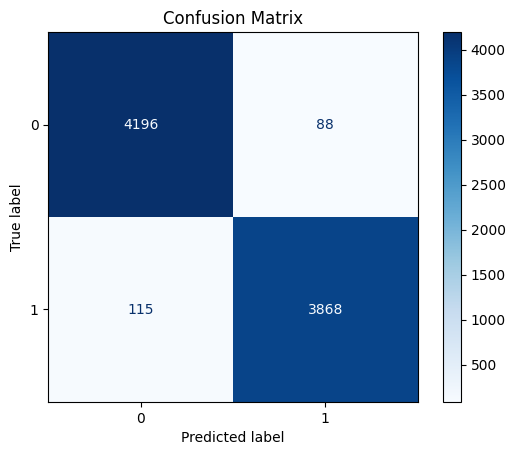

In [24]:
import joblib
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

def process_and_analyze_data(train_data, test_data):
    """
    Process both training and test data using the same vectorizer to ensure feature consistency
    """
    # Create and fit the vectorizer on training data only
    tfidf_vectorizer = TfidfVectorizer()
    X_train_tfidf = tfidf_vectorizer.fit_transform(train_data['text'])
    
    # Transform test data using the same vectorizer
    X_test_tfidf = tfidf_vectorizer.transform(test_data['text'])
    
    # Print diagnostic information
    print("Data Shape Information:")
    print(f"Training features shape: {X_train_tfidf.shape}")
    print(f"Test features shape: {X_test_tfidf.shape}")
    print(f"Number of features (vocabulary size): {len(tfidf_vectorizer.get_feature_names_out())}")
    
    return X_train_tfidf, X_test_tfidf, tfidf_vectorizer

def train_and_evaluate_model(X_train_tfidf, X_test_tfidf, train_data, test_data):
    """
    Train the model and evaluate it on the test set
    """
    # Train the model
    from sklearn.ensemble import RandomForestClassifier
    model = RandomForestClassifier(n_estimators=100, random_state=42)
    model.fit(X_train_tfidf, train_data['label'])
    
    # Make predictions
    y_pred = model.predict(X_test_tfidf)
    
    # Generate confusion matrix
    cm = confusion_matrix(test_data['label'], y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
    disp.plot(cmap=plt.cm.Blues)
    plt.title('Confusion Matrix')
    plt.show()
    
    # Save the model and vectorizer
    joblib.dump(model, 'fake_news_model.pkl')
    joblib.dump(tfidf_vectorizer, 'tfidf_vectorizer.pkl')
    
    return model, y_pred

# Main execution
# Process the data
X_train_tfidf, X_test_tfidf, tfidf_vectorizer = process_and_analyze_data(train_data, test_data)

# Train and evaluate the model
model, predictions = train_and_evaluate_model(X_train_tfidf, X_test_tfidf, train_data, test_data)

Data Shape Information:
Training features shape: (29908, 103116)
Test features shape: (8267, 103116)
Number of features (vocabulary size): 103116


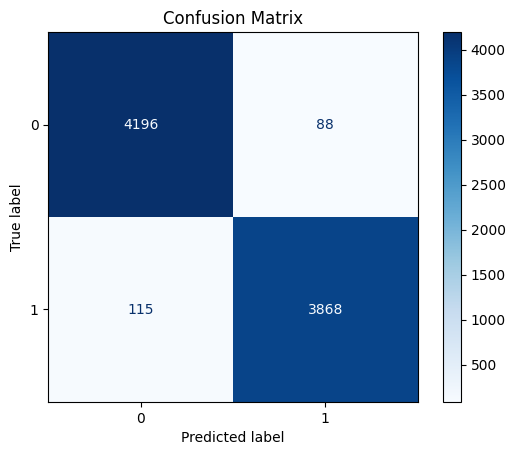

In [25]:
# Assuming train_data and test_data are your dataframes
X_train_tfidf, X_test_tfidf, tfidf_vectorizer = process_and_analyze_data(train_data, test_data)
model, predictions = train_and_evaluate_model(X_train_tfidf, X_test_tfidf, train_data, test_data)

In [26]:
# Save the properly processed model and vectorizer with new names to avoid confusion
joblib.dump(model, 'fake_news_model_updated.pkl')
joblib.dump(tfidf_vectorizer, 'tfidf_vectorizer_updated.pkl')

print("Models saved successfully!")

Models saved successfully!


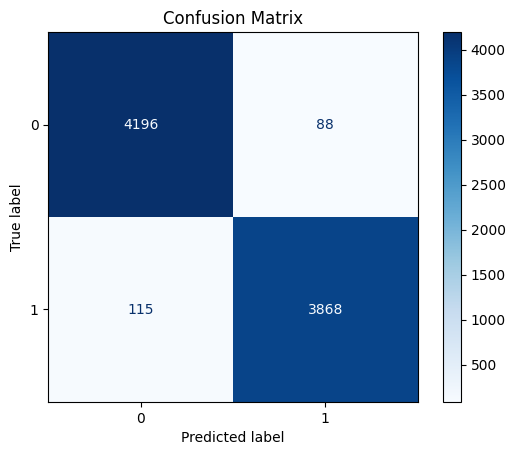


Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.98      0.98      4284
           1       0.98      0.97      0.97      3983

    accuracy                           0.98      8267
   macro avg       0.98      0.98      0.98      8267
weighted avg       0.98      0.98      0.98      8267



In [27]:
import joblib
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt

def load_models_and_predict(model_path, vectorizer_path, test_data):
    """
    Load the saved models and make predictions on test data
    """
    # Load the saved models
    model = joblib.load(model_path)
    tfidf_vectorizer = joblib.load(vectorizer_path)
    
    # Transform test data using the loaded vectorizer
    X_test_tfidf = tfidf_vectorizer.transform(test_data['text'])
    
    # Make predictions
    predictions = model.predict(X_test_tfidf)
    
    # Generate and display confusion matrix
    cm = confusion_matrix(test_data['label'], predictions)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
    disp.plot(cmap=plt.cm.Blues)
    plt.title('Confusion Matrix')
    plt.show()
    
    # Print classification report
    print("\nClassification Report:")
    print(classification_report(test_data['label'], predictions))
    
    return predictions

# Load models and make predictions
predictions = load_models_and_predict(
    'fake_news_model_updated.pkl',
    'tfidf_vectorizer_updated.pkl',
    test_data
)

# Add predictions to test_data if needed
test_data['predicted_label'] = predictions